T = 3.5, beta = 5,
u = np.linspace(0, 1, 31)
checkpoint_times = T * (u ** 12) # more rapid changes closer to 0

In [1]:

import numpy as np
from tests import (
    test_shuffle_gillespie, 
    test_nmc_convergence_gillespie,
    test_joint_vs_full_marginal,
    test_hellinger_vs_k,
    test_approximation_error_vs_nmc,
    test_marginal_hellinger_vs_M
    )

# Test 1: Gillespie's Algorithm
1. Test and plot how Hellinger distance decreases as n_mc increases
    1. try for a realtively large value, maybe N = 8, r, 10, L = 3, different n_mc
2. Test and plot
    - choose N, r, L, n_mc and plot gillespies and forward hellinger distance
    - shuffle particles generated by gillespies and forward with each other and plot the hellinger distance in the same plot, see maybe to do confidence intervals with bootstraping. do this for small N, r, n_mc etc


## Test 1.1: Higher n_mc decreases H

TEST: n_mc Convergence (Gillespie)

Problem parameters:
  N=4, L=3, r=10, beta=5.0, T=3.5, mu_seed=42
  checkpoints: 31
  nmc_list: [1000, 10000, 100000, 200000]

--- n_mc = 1000 ---
Running forward process...
Running Gillespie reverse process...
  Gillespie particle 0/1000

--- n_mc = 10000 ---
Running forward process...
Running Gillespie reverse process...
  Gillespie particle 0/10000

--- n_mc = 100000 ---
Running forward process...
Running Gillespie reverse process...
  Gillespie particle 0/100000

--- n_mc = 200000 ---
Running forward process...
Running Gillespie reverse process...
  Gillespie particle 0/200000
  Gillespie particle 100000/200000

Generating plot...
Plot saved to: test_nmc_convergence_gillespie.png


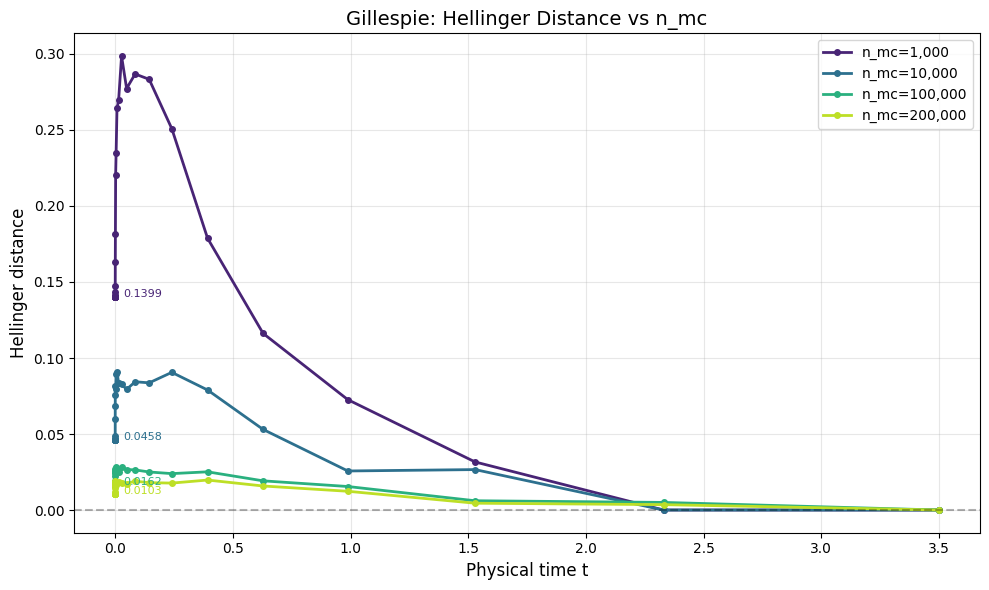


HELLINGER DISTANCES AT KEY CHECKPOINTS
n_mc                 t=0       t=T/4       t=T/2      t=3T/4         t=T
------------------------------------------------------------------------
1000              0.1399      0.0726      0.0316      0.0000      0.0000
10000             0.0458      0.0257      0.0266      0.0000      0.0000
100000            0.0162      0.0155      0.0061      0.0050      0.0000
200000            0.0103      0.0123      0.0045      0.0035      0.0000


In [5]:
N, L, r = 4, 3, 10
w = np.ones(r) / r
beta, T = 5.0, 3.5

u = np.linspace(0, 1, 31)
checkpoint_times = T * (u ** 12)
mu_seed = 42

results = test_nmc_convergence_gillespie(
    N=N, L=L, r=r, w=w,
    beta=beta, T=T,
    nmc_list=[1_000, 10_000, 100_000, 200_000],
    checkpoint_times=checkpoint_times,
    mu_seed=mu_seed,
)

## Test 1.2: shuffling Gillespie particles

TEST: Shuffle Gillespie

Problem parameters:
  N=4, L=3, r=10, beta=5.0, T=3.5, n_mc=50000
  checkpoints: 31  (mu_seed=42)
Running forward process...
Running Gillespie reverse process...
  Gillespie particle 0/50000

Computing true Hellinger distances...
Computing single-shuffle null distances...

Generating plot...
Plot saved to: test_shuffle_gillespie.png


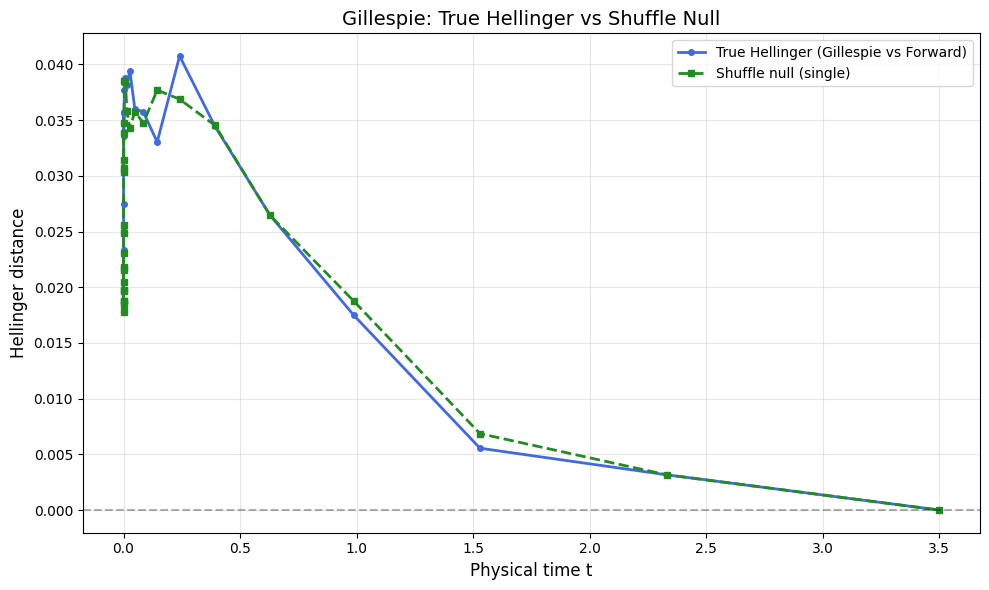


SUMMARY
  True Hellinger   — mean: 0.0269  max: 0.0408  at t=0: 0.0218
  Shuffle null     — mean: 0.0256  max: 0.0385  at t=0: 0.0215


In [ ]:
N, L, r = 4, 3, 10
beta, T = 5.0, 3.5
u = np.linspace(0, 1, 31)
checkpoint_times = T * (u ** 12)

w = np.ones(r) / r
n_mc = 50_000
mu_seed = 42



samples, original_distances, shuffle_distances = test_shuffle_gillespie(
    N=N, L=L, r=r, w=w,
    beta=beta, T=T, n_mc=n_mc,
    checkpoint_times=checkpoint_times,
    mu_seed=mu_seed,
    confidence_intervals=False,
)

TEST: Shuffle Gillespie

Problem parameters:
  N=4, L=3, r=10, beta=5.0, T=3.5, n_mc=50000
  checkpoints: 31  (mu_seed=42)
Running forward process...
Running Gillespie reverse process...
  Gillespie particle 0/50000

Computing true Hellinger distances...
Computing single-shuffle null distances...
Running 100 bootstrap shuffles for CI (level=0.95)...
  Bootstrap 0/100

Generating plot...
Plot saved to: test_shuffle_gillespie.png


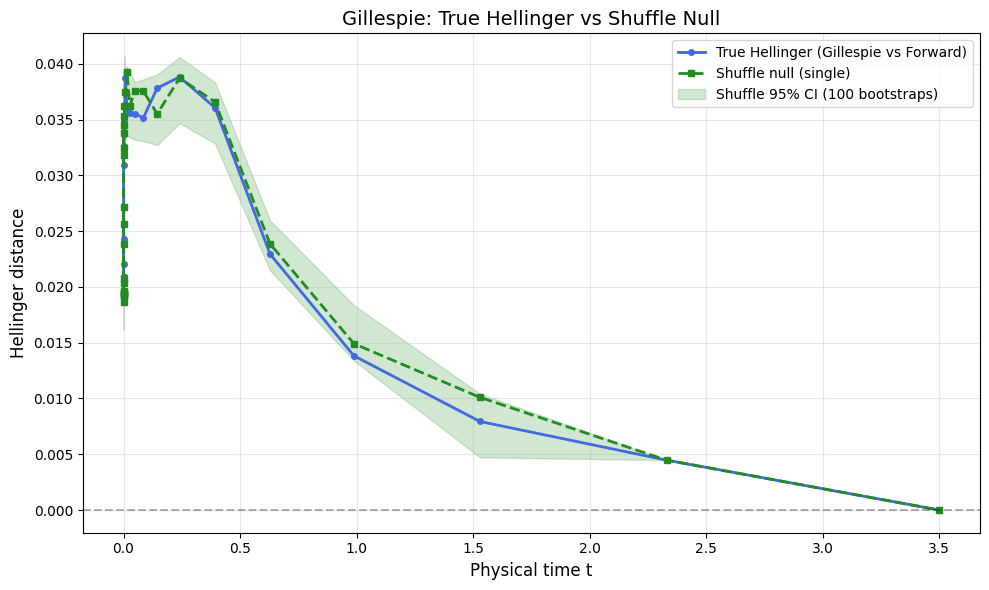


SUMMARY
  True Hellinger   — mean: 0.0260  max: 0.0388  at t=0: 0.0209
  Shuffle null     — mean: 0.0261  max: 0.0393  at t=0: 0.0239
  Shuffle CI [95%] at t=0: [0.0166, 0.0233]


In [4]:
samples, original_distances, shuffle_distances = test_shuffle_gillespie(
    N=N, L=L, r=r, w=w,
    beta=beta, T=T, n_mc=n_mc,
    checkpoint_times=checkpoint_times,
    mu_seed=42,
    confidence_intervals=True,
    n_bootstrap=100,
    ci_level=0.95,
)

# Test 2: More efficient computing of distance
1. Show that Partial hellinger is a good approximation of joint Hellinger
    - Sanity Check: that Partial Hellinger with k = N is equal to the joint Hellinger
    - Convergence Plot: H(k) vs k for Small N
    - Approximation Error vs n_mc
            Show that the gap |H_marginal(k=r) - H_joint| shrinks as n_mc grows, while the computational cost of full joint H explodes. This is the efficiency argument:

            At small n_mc: full joint H is unreliable (sparse histograms), marginal H(k=r) is already stable
            At large n_mc: both converge to the same value
            Marginal H(k=r) reaches a reliable estimate with far fewer samples

            Plot two curves vs n_mc:

            H_joint(n_mc) — show it is still noisy at moderate n_mc



2. Test and plot how average marginal Hellinger does not depend on M. Explain the detailed mathematical reason why (conditional independence of dimensions given mixture component)
2. Show how when k $\approx r$ the hellinger distance computed is approx the one when $k = N$, so the full joint marginal. Explain mathematically why.
    - Test should be run on N = 15, L = 2, r = 5, k = 3,4,5,6,7

**DECIDE ON**: define problem. choose N, L, r and keep throught out thesis
- N = 20,
- L = 5,
- r = 5
- k = 4

**POTENTIALLY** do this in the end:
3. Ranking Consistency Test
The practical purpose of H is to rank methods — you want to say "method A is closer to forward than method B". So test whether marginal H(k=r) gives the same ranking as full joint H across multiple methods.
Run several methods (Gillespie, tau=0.1, tau=0.2, tau=0.4) and compare:

Rankings by full joint H
Rankings by marginal H(k=r)

If the rankings agree, the marginal H is a reliable proxy for the purpose you actually care about — comparing methods — even if the absolute values differ slightly.

## Test 2.1: Marginal Hellinger as good approximator

TEST: Joint Hellinger == Marginal Hellinger (k=N)

Problem parameters:
  N=10, L=2, r=5, beta=5.0, T=3.5, n_mc=50000, mu_seed=42
  method=gillespie, k=N=10
Running forward process...
Running Gillespie reverse process...
  Gillespie particle 0/50000

Computing joint Hellinger distances...
Computing marginal Hellinger distances (k=N, M=1)...

JOINT vs MARGINAL (k=N) HELLINGER AT KEY CHECKPOINTS
checkpoint           t=0       t=T/4       t=T/2      t=3T/4         t=T
------------------------------------------------------------------------
Joint             0.0772      0.0337      0.0108      0.0077      0.0000
Marginal k=N      0.0772      0.0337      0.0108      0.0077      0.0000
Difference        0.0000      0.0000      0.0000      0.0000      0.0000

Generating plot...
Plot saved to: test_joint_vs_full_marginal.png


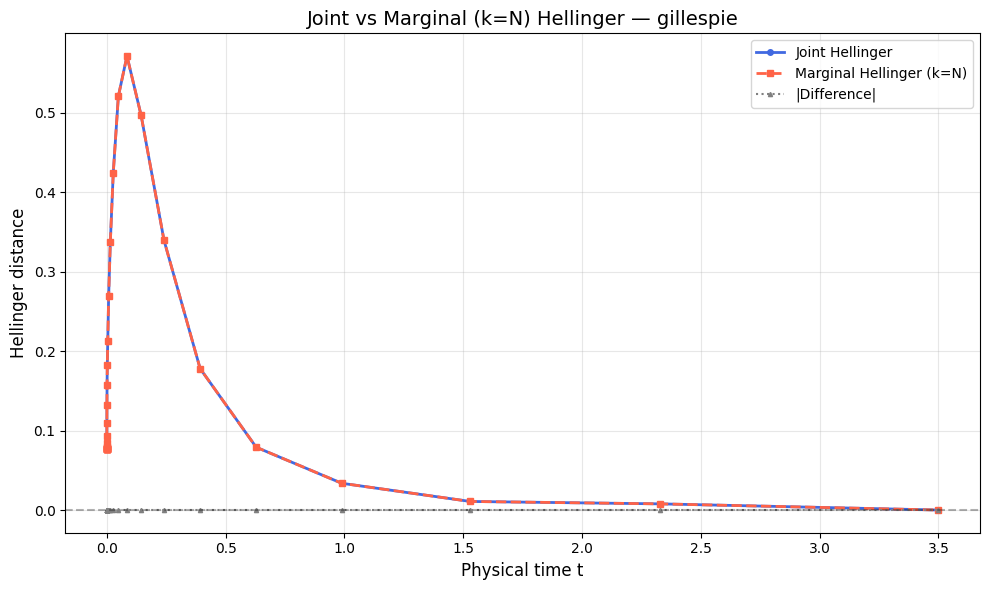


✓ PASSED — max |difference| = 0.00e+00 < 1.00e-10


In [ ]:


N, L, r = 10, 2, 5 
w = np.ones(r) / r
beta, T = 5.0, 3.5
mu_seed = 42

u = np.linspace(0, 1, 31)
checkpoint_times = T * (u ** 12)

joint_distances, marginal_distances = test_joint_vs_full_marginal(
    N=N, L=L, r=r, w=w,
    beta=beta, T=T, n_mc=50_000,
    checkpoint_times=checkpoint_times,
    method='gillespie',
    mu_seed=mu_seed,
)

TEST: H(k) vs k

Problem parameters:
  N=10, L=2, r=5, beta=5.0, T=3.5, n_mc=250000, mu_seed=42
  method=gillespie, k_list=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
Running forward process...
Running Gillespie reverse process...
  Gillespie particle 0/250000
  Gillespie particle 100000/250000
  Gillespie particle 200000/250000

Computing marginal Hellinger for each k...
  k=1 ...
  k=2 ...
  k=3 ...
  k=4 ...
  k=5 ...
  k=6 ...
  k=7 ...
  k=8 ...
  k=9 ...
  k=10 ...

H(k) AT KEY CHECKPOINTS
k                t=0       t=T/4       t=T/2      t=3T/4         t=T
--------------------------------------------------------------------
1             0.0012      0.0002      0.0000      0.0020      0.0000
2             0.0020      0.0014      0.0012      0.0023      0.0000
3             0.0022      0.0036      0.0031      0.0041      0.0000
4             0.0027      0.0063      0.0041      0.0046      0.0000
5             0.0048      0.0080      0.0036      0.0039      0.0000
6             0.0080      0.

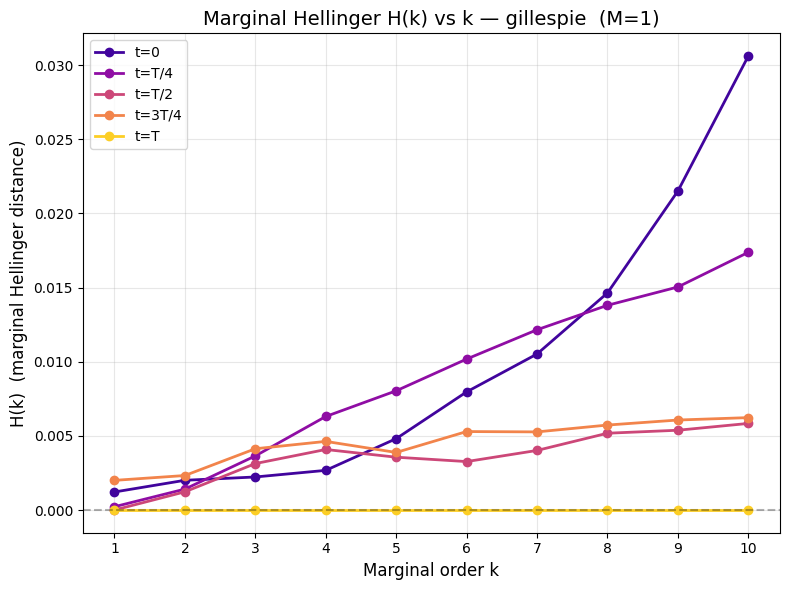

In [3]:
N, L, r = 10 , 2, 5
w = np.ones(r) / r
beta, T = 5.0, 3.5
mu_seed = 42
u = np.linspace(0, 1, 31)
checkpoint_times = T * (u ** 12)

results = test_hellinger_vs_k(
    N=N, L=L, r=r, w=w,
    beta=beta, T=T, n_mc=250_000,
    checkpoint_times=checkpoint_times,
    k_list=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10],   
    method='gillespie',
    mu_seed=mu_seed,
)

Here, makes sense that as k increases H increases as the size of possible states increases as L^k, so approximating H would require more and more samples. Idea is to keep track of this and then in tau leaping we remove the error from gillespies as that is "normal" and then check how tau leaping is doing

TEST: Approximation Error vs n_mc

Problem parameters:
  N=10, L=2, r=5, beta=5.0, T=3.5, mu_seed=42
  method=gillespie, k=5, evaluating at t=0.0
  nmc_list=[500, 1000, 5000, 10000, 50000, 100000]
  Reference: H_joint at n_mc=100000

--- n_mc = 500 ---
Running forward process...
Running Gillespie reverse process...
  Gillespie particle 0/500

--- n_mc = 1000 ---
Running forward process...
Running Gillespie reverse process...
  Gillespie particle 0/1000

--- n_mc = 5000 ---
Running forward process...
Running Gillespie reverse process...
  Gillespie particle 0/5000

--- n_mc = 10000 ---
Running forward process...
Running Gillespie reverse process...
  Gillespie particle 0/10000

--- n_mc = 50000 ---
Running forward process...
Running Gillespie reverse process...
  Gillespie particle 0/50000

--- n_mc = 100000 ---
Running forward process...
Running Gillespie reverse process...
  Gillespie particle 0/100000

RESULTS AT t=0  (reference H_joint = 0.0521)
n_mc                 H_joint H_margin

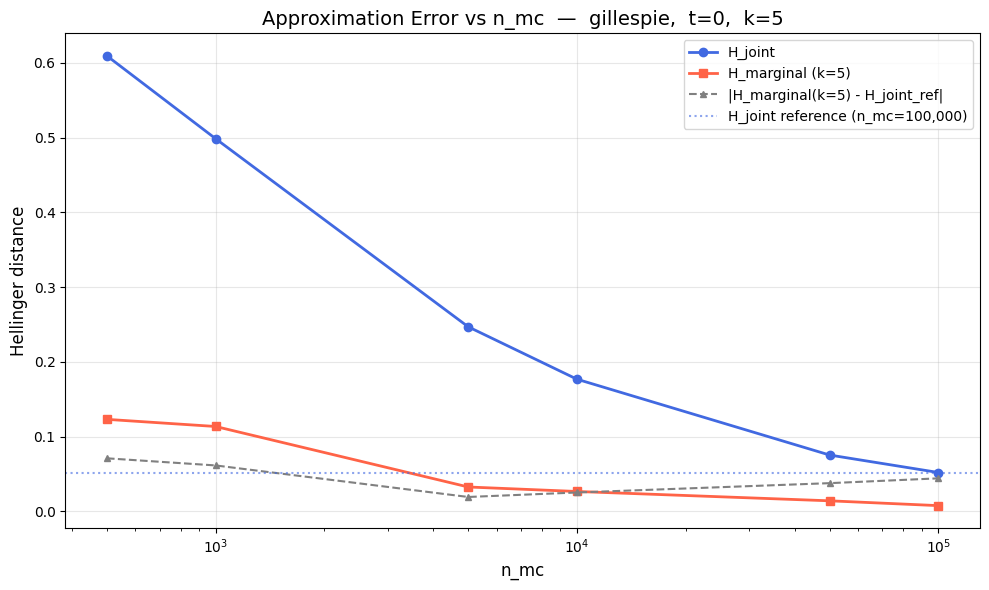

In [2]:
N, L, r = 10, 2, 5
w = np.ones(r) / r
beta, T = 5.0, 3.5

u = np.linspace(0, 1, 31)
checkpoint_times = T * (u ** 12)
mu_seed = 42

h_joint, h_marginal, h_joint_ref = test_approximation_error_vs_nmc(
    N=N, L=L, r=r, w=w,
    beta=beta, T=T,
    nmc_list=[500, 1_000, 5_000, 10_000, 50_000, 100_000],
    checkpoint_times=checkpoint_times,
    k=r,
    method='gillespie',
    mu_seed=mu_seed,
)

## Test 2.2: Marginal Hellinger does not depend on M

TEST: Marginal Hellinger vs M (bootstrapped)

Problem parameters:
  N=10, L=2, r=5, beta=5.0, T=3.5, n_mc=50000, mu_seed=42
  method=gillespie
  k_list=[1, 2, 3, 5], M_list=[1, 5, 10, 20]
  n_bootstrap=50, ci_level=0.95
Running forward process...
Running Gillespie reverse process...
  Gillespie particle 0/50000

  Bootstrapping k=1, M=1  (50 replicates)...

  Bootstrapping k=1, M=5  (50 replicates)...

  Bootstrapping k=1, M=10  (50 replicates)...

  Bootstrapping k=1, M=20  (50 replicates)...

  Bootstrapping k=2, M=1  (50 replicates)...

  Bootstrapping k=2, M=5  (50 replicates)...

  Bootstrapping k=2, M=10  (50 replicates)...

  Bootstrapping k=2, M=20  (50 replicates)...

  Bootstrapping k=3, M=1  (50 replicates)...

  Bootstrapping k=3, M=5  (50 replicates)...

  Bootstrapping k=3, M=10  (50 replicates)...

  Bootstrapping k=3, M=20  (50 replicates)...

  Bootstrapping k=5, M=1  (50 replicates)...

  Bootstrapping k=5, M=5  (50 replicates)...

  Bootstrapping k=5, M=10  (50 repli

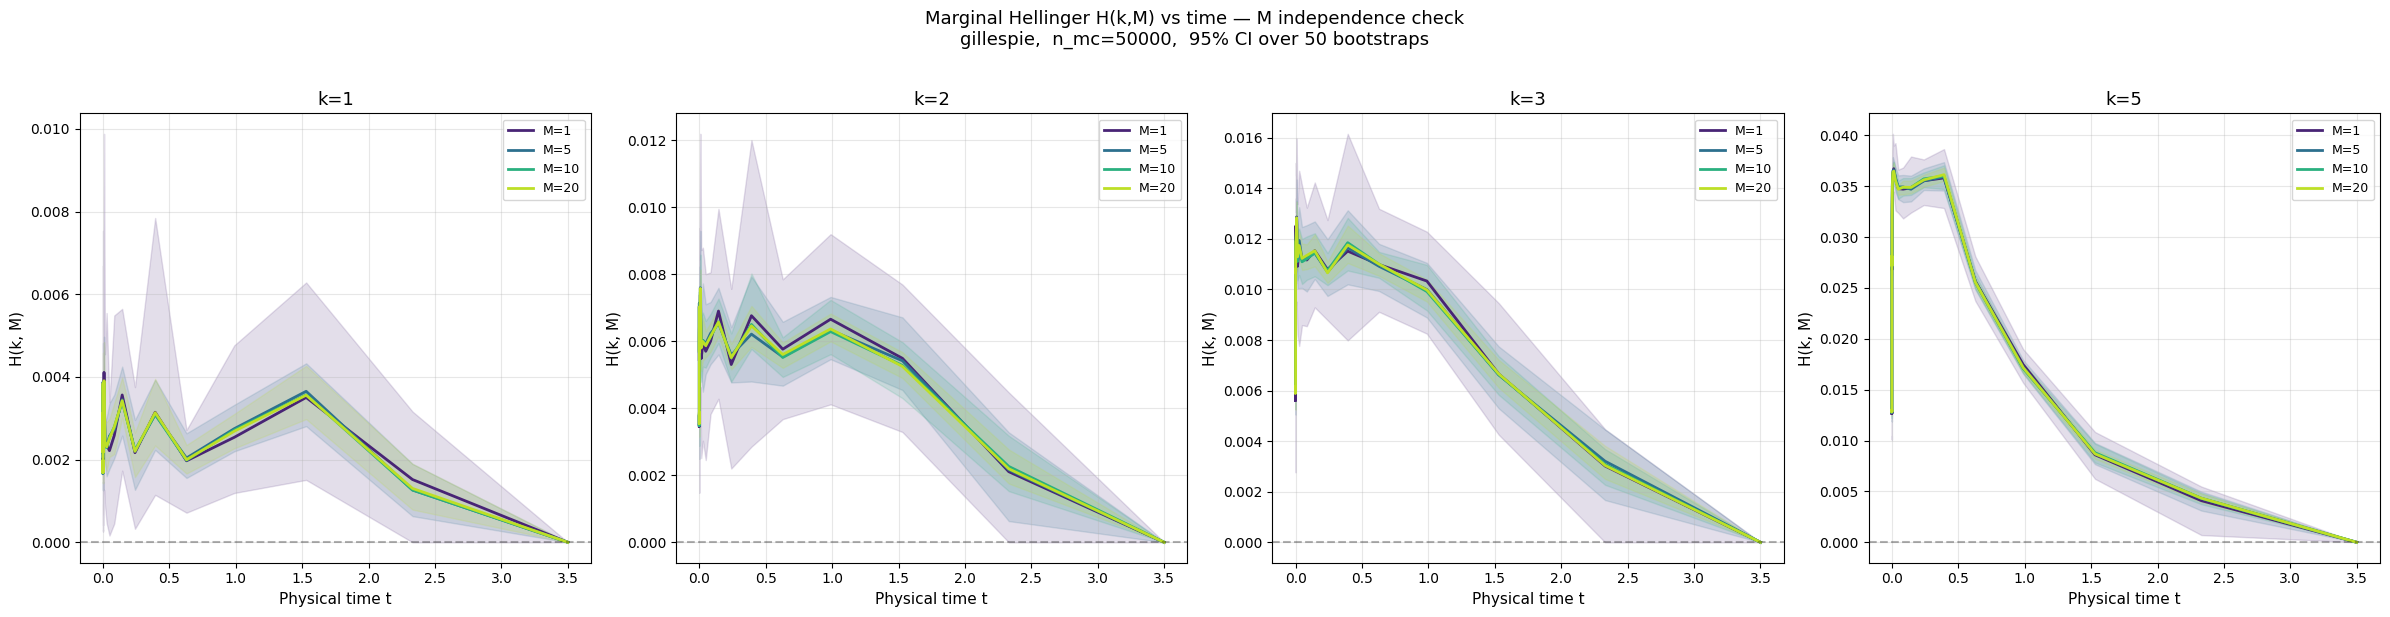


MEAN H(k, M) AT t=0  (95% CI)
(k, M)                      mean               CI_lo               CI_hi
------------------------------------------------------------------------
(1, 1)                    0.0017              0.0003              0.0027
(1, 5)                    0.0017              0.0013              0.0021
(1, 10)                   0.0017              0.0017              0.0017
(1, 20)                   0.0017              0.0014              0.0020
(2, 1)                    0.0035              0.0015              0.0066
(2, 5)                    0.0035              0.0025              0.0049
(2, 10)                   0.0035              0.0029              0.0041
(2, 20)                   0.0035              0.0032              0.0040
(3, 1)                    0.0056              0.0028              0.0074
(3, 5)                    0.0060              0.0051              0.0070
(3, 10)                   0.0059              0.0053              0.0067
(3, 20)             

In [2]:
N, L, r = 10, 2, 5
w = np.ones(r) / r
beta, T = 5.0, 3.5

u = np.linspace(0, 1, 31)
checkpoint_times = T * (u ** 12)
mu_seed = 42

results = test_marginal_hellinger_vs_M(
    N=N, L=L, r=r, w=w,
    beta=beta, T=T, n_mc=50_000,
    checkpoint_times=checkpoint_times,
    k_list=[1, 2, 3, 5],
    M_list=[1, 5, 10, 20],
    method='gillespie',
    mu_seed=mu_seed,
    n_bootstrap=50,
    ci_level=0.95,
)

# Test 3: Tau-Leaping
1. Test and plot how for given N, r, L, and n_mc the Hellinger distance changes at different $\tau$ values
2. Plot at a given dimension the distribution across vocabulary values. (histogram)
    - Maybe try this with intentionally skewed dirichlet distributions
3. H_corrected(k) = H_tau(k) - H_gillespie(k)
4. look at diversity as baseline

$\tau \in {0.005, 0.008, 0.01, 0.2, 0.3, 0.4, 0.5, 1}$


**DECIDE ON:** value of $\tau$

# Test 4: Random Masking corrector
1. testing, plotting, explaining why with math of why $R^c = R$ and $R^C = R + \hat{R}$ perform nearly identically. when plotting why they are identical, do some bootstrapping ot get confidence in tervals. Never state they are identical, say they are approximately identical
2. Test $start\_time \in {0.5, 1.5, 2.5, 3.5} $
3. Test $n_{corr} \in {1,2,4,8}$ 
4. test $\tau_c \in {0.001, 0.005, 0.01, 0.2, 0.4, 0.6, 1}$ (adjust set after Test 3 done depending on value chosen there as 'optimal')
5. Test diveristy by plotting histogram of vocabulary for given dimensions 
    - compare it to the one from the normal tau leap experiment

# Test 5: DPC corrector
1. 
2. Test $start\_time \in {0.5, 1.5, 2.5, 3.5} $
3. Test $n_{corr} \in {1,2,4,8}$ 
5. Test diveristy by plotting histogram of vocabulary for given dimensions 
    - compare it to the one from the normal tau leap experiment

# Test 6: Informed Corrector corrector
2. Test $start\_time \in {0.5, 1.5, 2.5, 3.5} $
3. Test $n_{corr} \in {1,2,4,8}$ 
5. Test diveristy by plotting histogram of vocabulary for given dimensions 
    - compare it to the one from the normal tau leap experiment

# Test 7: PRISM corrector
1. Test $\eta \in {0.002, 0.02, 0.2, 2} $
2. Test $start\_time \in {0.5, 1.5, 2.5, 3.5} $

5. Test diveristy by plotting histogram of vocabulary for given dimensions 
    - compare it to the one from the normal tau leap experiment